# Option B : Cost and Performance Optimization for Application Deployment and Scaling

## DIA_4
### Axel Juillard, TimothÃƒÆ’Ã‚Â©e Joliot, LÃƒÆ’Ã‚Â©o-Paul ChauvignÃƒÆ’Ã‚Â©


## Problem context

 Modern Machine Learning models, especially in fields like Deep Learning, are becoming increasingly
 large and complex. Training these models on a single machine can take weeks or even months, creating a
 significant bottleneck in the AI development cycle. To accelerate this process, companies use distributed
 training, where the computational workload is spread across multiple machines in a cloud environment.
 This approach can drastically reduce training time, but it introduces a major challenge: cost and
 resource management.

 Efficiently allocating cloud resources for a distributed training job is a critical problem in MLOps (Machine Learning Operations). A poorly configured cluster can lead to enormous cloud bills with little performance gain, or worse, training failures. Conversely, an optimal configuration can save thousands of dollars and significantly shorten the time to model deployment.

## Problem Definition

 An AI team needs to train a large-scale machine learning model using a distributed architecture on
 a cloud platform. The objective is to configure the training cluster to minimize the total hourly
 infrastructure cost while ensuring the training process is stable and efficient.

### ---

In other words, we look at a machine learning application running in the cloud. It is made of several components that work together (For example : Data Preprocessing, Feature Engineering, Model Training). Each of these components can run on several virtual machines at the same time to handle a higher workload in parallel, which is what we call distributed training.


The cloud provider here gives us different VM types with different CPU, RAM and price per hour with there being a limit to how many virtual machines of the same type we can use.

Our job is to decide based on the workload:

- How many VMs of each type we rent
- How we place the different components of the application on these VMs  

So as to minimize the cost of renting the VM all the while having enough computing power to assure a stable handling of the workload.

From an algorithmic point of view, this is a hard combinatorial optimisation problem: there are many possible combinations of VM counts and component replicas, and checking feasibility involves several constraints. We will tackle this using two AI algorithms from the course (one exact or constraint-based approach and one heuristic or metaheuristic approach) and compare their performance.

## Problem Constraints

This problem is composed of 3 main constraints which we will adress in our solution :

- Resource sufficiency. The total resources (CPU and RAM) provided by the chosen VMs must
 be greater than or equal to the total resources required by all component replicas combined.
- Training stability (Queuing Concept). To prevent bottlenecks, the cluster must be able to
 process incoming requests faster than they arrive.
- VM availability. The number of provisioned VMs of a given type cannot exceed the availability
 limit specified in the catalogue.

## Problem Data

### "VM_Catalogue.xlsx"
   - Each row describes one VM type  
   - Columns: 
      - type identifier, 
      - CPU capacity, 
      - RAM capacity, 
      - hourly cost, 
      - maximum available quantity  
   - This defines the search space of possible VM choices and is used to compute the cost of a deployment

### "Workload.xlsx"  
   - Time series of incoming request rates  
   - Columns: time index and input_rate  
   - This defines the load that the system must be able to handle and is used to compute how many replicas are needed for stability

## Data Loading & Exploration

In [29]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\leopa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Imports

In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Data loading

In [31]:
# Paths of data files
VM_CATALOGUE_PATH = "OptionB_Data\VM_Catalogue.xlsx"
WORKLOAD_PATH = "OptionB_Data\Workload.xlsx"

vmDF = pd.read_excel(VM_CATALOGUE_PATH, header=1)
workloadDF = pd.read_excel(WORKLOAD_PATH)

In [39]:
vmDF.head(18)

,Type,CPU,RAM,Cost,Quantity
0,T00,1,3.75,0.191,10
1,T01,2,1.80,0.210,10
2,T02,2,7.50,0.268,10
3,T03,2,13.00,0.294,10
4,T04,4,3.60,0.306,10
5,T05,4,15.00,0.422,10
6,T06,4,26.00,0.474,10
7,T07,8,7.20,0.498,10
8,T08,8,30.00,0.730,10
9,T09,8,52.00,0.834,10


In [33]:
workloadDF.head()

,time,input_rate
0,0,340
1,1,469
2,2,541
3,3,378
4,4,396


### Quick validation of loaded data

Before moving on to modeling, we sanity-check the datasets we just loaded to confirm shapes, columns, and missing values.


In [34]:
print('VM catalogue columns:', list(vmDF.columns), '\n')
print('Workload columns:', list(workloadDF.columns))


VM catalogue columns: ['Type', 'CPU', 'RAM', 'Cost', 'Quantity'] 

Workload columns: ['time', 'input_rate']


In [35]:
print(f'VM catalogue shape: {vmDF.shape}\n')
print(f'Workload shape: {workloadDF.shape}')



VM catalogue shape: (17, 5)

Workload shape: (1259, 2)


In [36]:
print('Missing values per column (VM catalogue):')
print(vmDF.isna().sum(), '\n')

print('Missing values per column (Workload):')
print(workloadDF.isna().sum())

Missing values per column (VM catalogue):
Type        0
CPU         0
RAM         0
Cost        0
Quantity    0
dtype: int64 

Missing values per column (Workload):
time          0
input_rate    0
dtype: int64


All expected columns listed in the project statement are present, shapes match the described schema (17 VM types, 1,259 workload points), and there are no missing values.


### Problem formulation

We are modeling the problem for one application made of 4 components.

For each component i we know:

  - mu_i = service rate of component i (how fast one replica can work, for example its requests per second)
  
  - cpu_req_i (how much CPU one replica needs)

  - ram_req_i (ow much RAM one replica needs)

  
  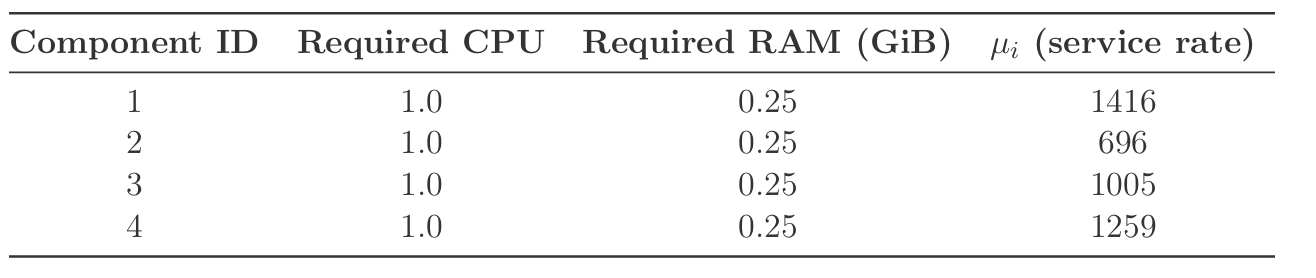


In [37]:
# Component parameters
# For each parameter we define a dictionary contatining the specifications for each component.
cpu_req = {
    0: 1.0,
    1: 1.0,
    2: 1.0,
    3: 1.0,
}

ram_req = {
    0: 0.25,
    1: 0.25,
    2: 0.25,
    3: 0.25,
}

mu = {
    0: 1416,
    1: 696,    
    2: 1005,   
    3: 1259,   
}

For each VM type j in the catalogue we know:

  - CPU_j (how much CPU one VM of this type has)

  - RAM_j (how much RAM one VM of this type has)

  - Cost_j (how much it costs per hour)

  - Qty_j (the maximum number of VMs of this type we are allowed to rent)

In [40]:
# We transform the VM catalogue dataframe into dictionaries for ease of use later on when coding the algorithms

cpu_vm = vmDF["CPU"].to_dict()
ram_vm = vmDF["RAM"].to_dict()
cost_vm = vmDF["Cost"].to_dict()
qty_vm  = vmDF["Quantity"].to_dict()

From the workload file we load the input rate / arrival rate, λi

For each λi we want to choose r_i, the number of replicas of component i and x_j, the number of VMs of type j that we rent so as to minimize the objective function : 

Cost(r, x) = sum over j of (Cost_j * x_j)

Satisfying the constraints : 

- r_i * mu_i > λi (stability)

    Constraint : Each component must have enough replicas to keep up with the incoming requests.

- [sum over i of (cpu_req_i * r_i)] <= [sum over j of (CPU_j * x_j)]
    
    Constraint: total CPU demand ≤ total CPU capacity.

- [ sum over i of (ram_req_i * r_i) ] <= [sum over j of (RAM_j * x_j) ]
    
    Constraint: total RAM demand ≤ total RAM capacity.